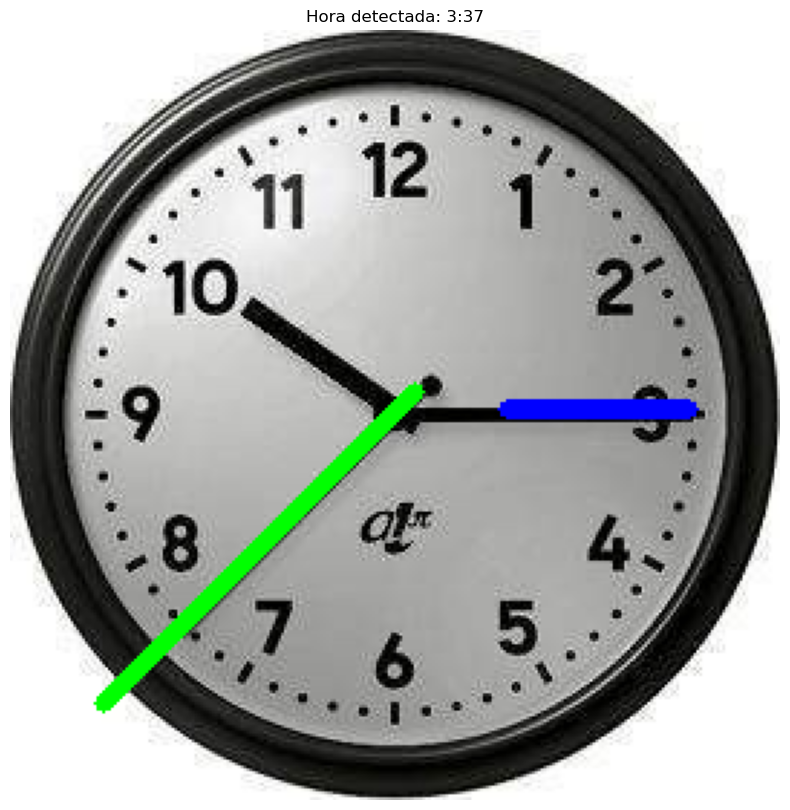

La hora detectada es: 3:37


In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('img8.jpg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)

# detección de bordes
bordes = cv2.Canny(gris, 50, 150)

#  líneas
lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)

# centro del reloj
centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

# calcular ángulo
def calcular_angulo(x1, y1, x2, y2):
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

manecillas = []
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y),np.hypot(x2 - centro_x, y2 - centro_y))
        if distancia_centro < 100 and 40 < longitud < 300:
            angulo = calcular_angulo(x1, y1, x2, y2)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })

if len(manecillas) >= 2:
    # más corta = horario, más larga = minutero
    manecillas.sort(key=lambda x: x['longitud'])
    horario = manecillas[0]
    minutero = manecillas[-1]
    
    # hora y minutos
    hora = int((horario['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)

    # la hora
    fraccion_hora = (horario['angulo'] / 30) % 12
    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12


    imagen_resultado = imagen_rgb.copy()
   # cv2.circle(imagen_resultado, (centro_x, centro_y), 5, (0, 0, 255), -1)
    cv2.line(imagen_resultado,
             (horario['puntos'][0], horario['puntos'][1]),
             (horario['puntos'][2], horario['puntos'][3]),
             (0, 0, 255), 5)  
    cv2.line(imagen_resultado,
             (minutero['puntos'][0], minutero['puntos'][1]),
             (minutero['puntos'][2], minutero['puntos'][3]),
             (0, 255, 0), 5)  

    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    plt.title(f'Hora detectada: {hora}:{minutos:02d}')
    plt.axis('off')
    plt.show()

    print(f"La hora detectada es: {hora}:{minutos:02d}")
else:
    print("No se detectaron suficientes manecillas.")


Segundero

PROBANDO DETECTOR DE RELOJ EN MÚLTIPLES IMÁGENES

▶ Procesando: img8.jpg
   ✓ HORA: 02:31:51
   ✓ Ángulos: H=68.0° M=188.0° S=308.0°

▶ Procesando: reloj.jpg
   ✓ HORA: 04:43:03
   ✓ Ángulos: H=143.0° M=263.0° S=23.0°

RESUMEN DE RESULTADOS

img8.jpg: 02:31:51

reloj.jpg: 04:43:03


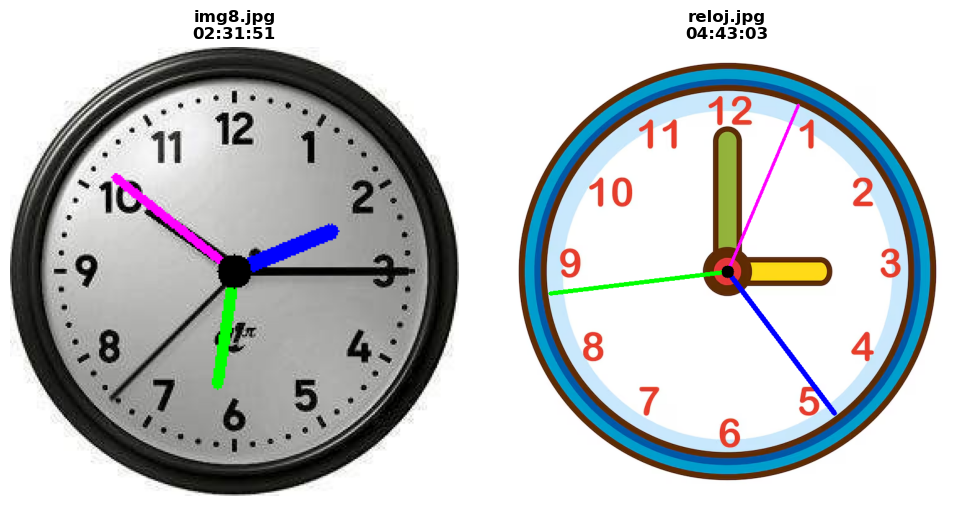

In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

print("=" * 80)
print("PROBANDO DETECTOR DE RELOJ EN MÚLTIPLES IMÁGENES")
print("=" * 80)

image_names = ['img8.jpg', 'reloj2.jpg', 'reloj1.jpg', 'reloj.jpg']

def detectar_hora_reloj(imagen_bgr, nombre_imagen):
    """Detecta la hora en una imagen de reloj"""
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    alto, ancho, _ = imagen_bgr.shape
    
    gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
    gris_blur = cv2.GaussianBlur(gris, (9, 9), 2)
    
    # Detectar centro
    circulos = cv2.HoughCircles(gris_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=100,
                                 param1=50, param2=30, minRadius=int(ancho*0.3), maxRadius=int(ancho*0.5))
    
    if circulos is not None:
        circulos = np.uint16(np.around(circulos))
        centro_x, centro_y, radio = circulos[0][0]
    else:
        centro_x, centro_y = ancho // 2, alto // 2
        radio = int(min(ancho, alto) * 0.4)
    
    # ESCANEO RADIAL
    picos_por_angulo = []
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    gris_clahe = clahe.apply(gris)
    
    for angulo_grados in range(0, 360, 1):
        angulo_rad = np.radians(angulo_grados)
        
        intensidades = []
        distancias = []
        
        for dist in np.linspace(10, radio, int(radio/1.5)):
            x = int(centro_x + dist * np.cos(angulo_rad))
            y = int(centro_y - dist * np.sin(angulo_rad))
            
            if 0 <= x < ancho and 0 <= y < alto:
                intensidades.append(gris_clahe[y, x])
                distancias.append(dist)
        
        if len(intensidades) > 20:
            intensidades = np.array(intensidades)
            gradiente = np.abs(np.diff(intensidades))
            
            if len(gradiente) > 0:
                max_grad_idx = np.argmax(gradiente[int(len(gradiente)*0.4):]) + int(len(gradiente)*0.4)
                
                if gradiente[max_grad_idx] > 20:
                    dist_borde = distancias[max_grad_idx]
                    
                    if dist_borde > radio * 0.3:
                        picos_por_angulo.append({
                            'angulo': float(angulo_grados),
                            'distancia': float(dist_borde),
                            'gradiente': float(gradiente[max_grad_idx])
                        })
    
    if len(picos_por_angulo) == 0:
        return None
    
    # Agrupar picos
    picos_por_angulo.sort(key=lambda x: x['angulo'])
    
    manecillas = []
    i = 0
    while i < len(picos_por_angulo):
        grupo = [picos_por_angulo[i]]
        j = i + 1
        
        while j < len(picos_por_angulo) and (picos_por_angulo[j]['angulo'] - picos_por_angulo[i]['angulo']) < 15:
            grupo.append(picos_por_angulo[j])
            j += 1
        
        ang_prom = np.mean([x['angulo'] for x in grupo])
        dist_prom = np.mean([x['distancia'] for x in grupo])
        grad_prom = np.mean([x['gradiente'] for x in grupo])
        
        manecillas.append({
            'angulo': float(ang_prom),
            'distancia': float(dist_prom),
            'gradiente': float(grad_prom),
            'count': len(grupo)
        })
        
        i = j
    
    # Convertir a sistema de reloj
    for m in manecillas:
        m['angulo_reloj'] = (90 - m['angulo']) % 360
    
    # Calcular scores
    for m in manecillas:
        m['score'] = m['distancia'] * np.sqrt(m['gradiente'])
    
    # Buscar mejor distribución
    mejor_combinacion = None
    mejor_distribucion = -1
    
    for i in range(len(manecillas)):
        for j in range(i+1, len(manecillas)):
            for k in range(j+1, len(manecillas)):
                m1, m2, m3 = manecillas[i], manecillas[j], manecillas[k]
                
                def dist_angular(a1, a2):
                    d = abs(a1 - a2)
                    return min(d, 360 - d)
                
                d12 = dist_angular(m1['angulo'], m2['angulo'])
                d23 = dist_angular(m2['angulo'], m3['angulo'])
                d31 = dist_angular(m3['angulo'], m1['angulo'])
                
                distribucion = -((120 - d12)**2 + (120 - d23)**2 + (120 - d31)**2)
                distribucion += (m1['score'] + m2['score'] + m3['score']) / 3 * 0.1
                
                if distribucion > mejor_distribucion:
                    mejor_distribucion = distribucion
                    mejor_combinacion = sorted([m1, m2, m3], key=lambda x: x['distancia'])
    
    if mejor_combinacion is None or len(mejor_combinacion) != 3:
        return None
    
    horario, minutero, segundero = mejor_combinacion
    
    # Convertir a hora/minuto/segundo
    hora = int((horario['angulo_reloj'] / 30) % 12)
    if hora == 0:
        hora = 12
    
    minutos = int((minutero['angulo_reloj'] / 6) % 60)
    segundos = int((segundero['angulo_reloj'] / 6) % 60)
    
    # Dibujar
    res_img = imagen_rgb.copy()
    
    for m, color, grosor in [(horario, (0,0,255), 8),
                              (minutero, (0,255,0), 5),
                              (segundero, (255,0,255), 3)]:
        ang_rad = np.radians(m['angulo'])
        x_fin = int(centro_x + m['distancia'] * np.cos(ang_rad))
        y_fin = int(centro_y - m['distancia'] * np.sin(ang_rad))
        cv2.line(res_img, (int(centro_x), int(centro_y)), (x_fin, y_fin), color, grosor)
    
    cv2.circle(res_img, (int(centro_x), int(centro_y)), 10, (0, 0, 0), -1)
    
    return {
        'hora': hora,
        'minutos': minutos,
        'segundos': segundos,
        'imagen': res_img,
        'horario_ang': horario['angulo_reloj'],
        'minutero_ang': minutero['angulo_reloj'],
        'segundero_ang': segundero['angulo_reloj']
    }

# Procesar cada imagen
resultados = []

for nombre in image_names:
    if os.path.exists(nombre):
        try:
            print(f"\n▶ Procesando: {nombre}")
            imagen = cv2.imread(nombre)
            
            resultado = detectar_hora_reloj(imagen, nombre)
            
            if resultado is not None:
                print(f"   ✓ HORA: {resultado['hora']:02d}:{resultado['minutos']:02d}:{resultado['segundos']:02d}")
                print(f"   ✓ Ángulos: H={resultado['horario_ang']:.1f}° M={resultado['minutero_ang']:.1f}° S={resultado['segundero_ang']:.1f}°")
                resultados.append((nombre, resultado))
            else:
                print(f"   ✗ No se detectaron manecillas")
        except Exception as e:
            print(f"   ✗ Error: {str(e)}")

# Mostrar resultados
if resultados:
    print("\n" + "=" * 80)
    print("RESUMEN DE RESULTADOS")
    print("=" * 80)
    
    for nombre, resultado in resultados:
        print(f"\n{nombre}: {resultado['hora']:02d}:{resultado['minutos']:02d}:{resultado['segundos']:02d}")
    
    # Mostrar imágenes
    if len(resultados) <= 4:
        fig, axes = plt.subplots(1, len(resultados), figsize=(5*len(resultados), 5))
        
        if len(resultados) == 1:
            axes = [axes]
        
        for idx, (nombre, resultado) in enumerate(resultados):
            axes[idx].imshow(resultado['imagen'])
            titulo = f"{nombre}\n{resultado['hora']:02d}:{resultado['minutos']:02d}:{resultado['segundos']:02d}"
            axes[idx].set_title(titulo, fontsize=12, fontweight='bold')
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
else:
    print("\n✗ No se procesó ninguna imagen exitosamente")

DETECTOR DE MANECILLAS DE RELOJ CON SEGUNDERO

✓ Imagen cargada: img8.jpg
✓ Centro detectado por HoughCircles: (133, 133), Radio: 132
✓ Picos radiales detectados: 360
✓ Manecillas agrupadas: 24

📊 MANECILLAS DETECTADAS:
   Horario (corta):    63.4px  ángulo=68.0°
   Minutero (media):   67.9px  ángulo=188.0°
   Segundero (larga):  89.7px  ángulo=308.0°

✓✓✓ HORA DETECTADA: 02:31:51 ✓✓✓


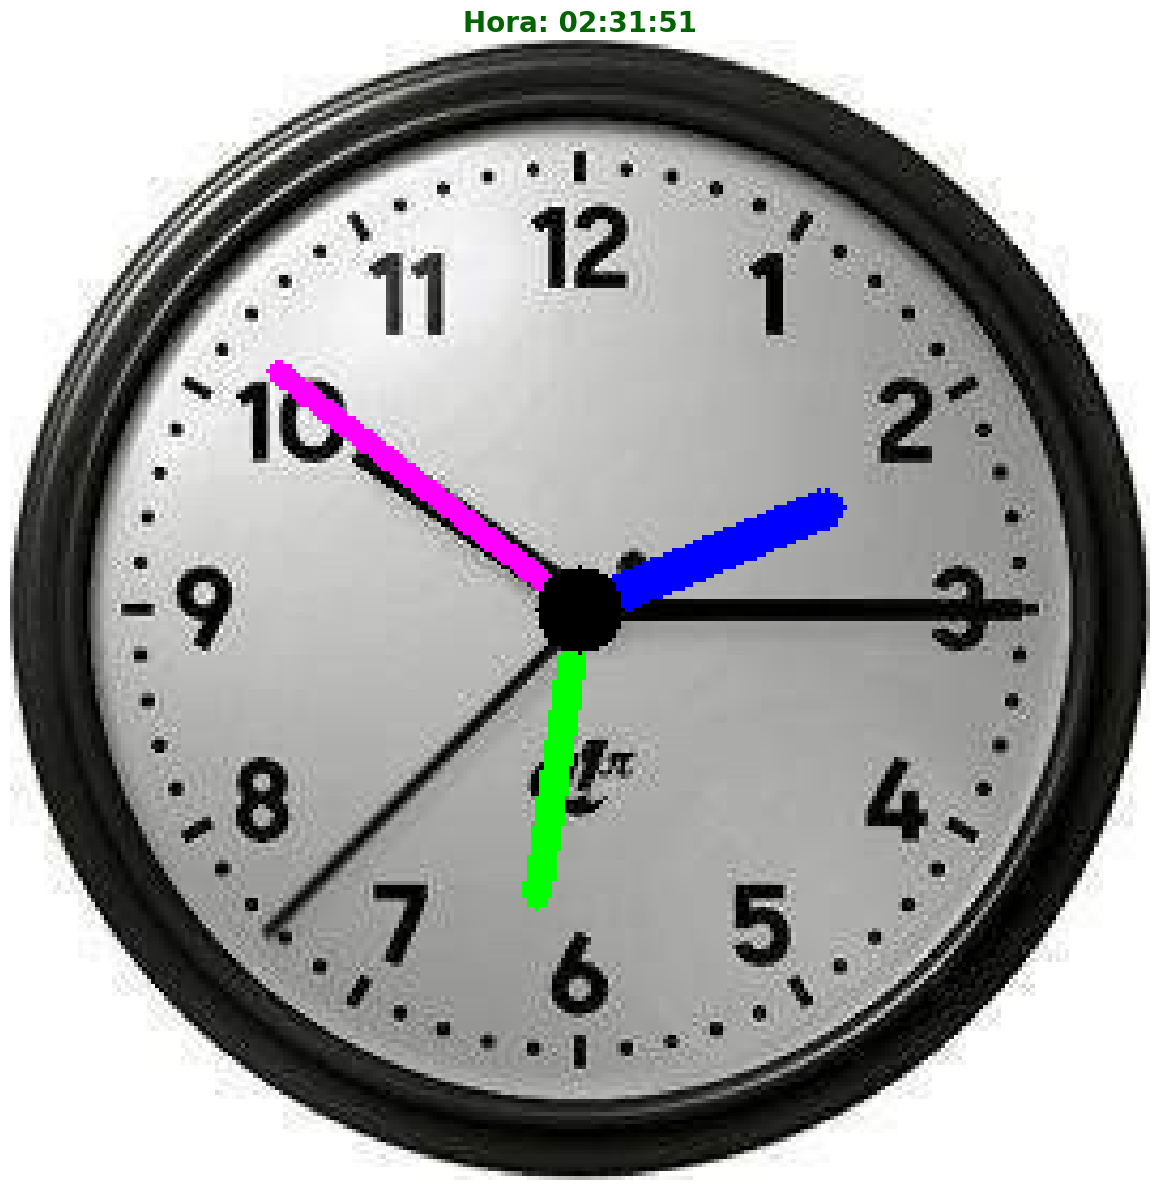


✓ Procesamiento completado exitosamente


In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

print("=" * 70)
print("DETECTOR DE MANECILLAS DE RELOJ CON SEGUNDERO")
print("=" * 70)

# Probar con múltiples imágenes
image_names = ['img8.jpg', 'reloj2.jpg', 'reloj1.jpg', 'reloj.jpg']
imagen_bgr = None
nombre_usado = None

for name in image_names:
    if os.path.exists(name):
        imagen_bgr = cv2.imread(name)
        if imagen_bgr is not None and imagen_bgr.size > 0:
            print(f"\n✓ Imagen cargada: {name}")
            nombre_usado = name
            break

if imagen_bgr is None:
    raise FileNotFoundError(f"No se encontró ninguna imagen: {image_names}")

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
alto, ancho, _ = imagen_bgr.shape

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris_blur = cv2.GaussianBlur(gris, (9, 9), 2)

# Detectar centro del reloj
circulos = cv2.HoughCircles(gris_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=100,
                             param1=50, param2=30, minRadius=int(ancho*0.3), maxRadius=int(ancho*0.5))

if circulos is not None:
    circulos = np.uint16(np.around(circulos))
    centro_x, centro_y, radio = circulos[0][0]
    print(f"✓ Centro detectado por HoughCircles: ({centro_x}, {centro_y}), Radio: {radio}")
else:
    centro_x, centro_y = ancho // 2, alto // 2
    radio = int(min(ancho, alto) * 0.4)
    print(f"⚠ Centro calculado por defecto: ({centro_x}, {centro_y}), Radio: {radio}")

# ESCANEO RADIAL: buscar manecillas mediante gradientes radiales
picos_por_angulo = []

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
gris_clahe = clahe.apply(gris)

for angulo_grados in range(0, 360, 1):
    angulo_rad = np.radians(angulo_grados)
    
    intensidades = []
    distancias = []
    
    for dist in np.linspace(10, radio, int(radio/1.5)):
        x = int(centro_x + dist * np.cos(angulo_rad))
        y = int(centro_y - dist * np.sin(angulo_rad))
        
        if 0 <= x < ancho and 0 <= y < alto:
            intensidades.append(gris_clahe[y, x])
            distancias.append(dist)
    
    if len(intensidades) > 20:
        intensidades = np.array(intensidades)
        gradiente = np.abs(np.diff(intensidades))
        
        if len(gradiente) > 0:
            max_grad_idx = np.argmax(gradiente[int(len(gradiente)*0.4):]) + int(len(gradiente)*0.4)
            
            if gradiente[max_grad_idx] > 20:
                dist_borde = distancias[max_grad_idx]
                
                if dist_borde > radio * 0.3:
                    picos_por_angulo.append({
                        'angulo': float(angulo_grados),
                        'distancia': float(dist_borde),
                        'gradiente': float(gradiente[max_grad_idx])
                    })

print(f"✓ Picos radiales detectados: {len(picos_por_angulo)}")

if len(picos_por_angulo) > 0:
    # Agrupar picos cercanos
    picos_por_angulo.sort(key=lambda x: x['angulo'])
    
    manecillas = []
    i = 0
    while i < len(picos_por_angulo):
        grupo = [picos_por_angulo[i]]
        j = i + 1
        
        while j < len(picos_por_angulo) and (picos_por_angulo[j]['angulo'] - picos_por_angulo[i]['angulo']) < 15:
            grupo.append(picos_por_angulo[j])
            j += 1
        
        ang_prom = np.mean([x['angulo'] for x in grupo])
        dist_prom = np.mean([x['distancia'] for x in grupo])
        grad_prom = np.mean([x['gradiente'] for x in grupo])
        
        manecillas.append({
            'angulo': float(ang_prom),
            'distancia': float(dist_prom),
            'gradiente': float(grad_prom),
            'count': len(grupo)
        })
        
        i = j
    
    # Convertir a sistema de reloj
    for m in manecillas:
        m['angulo_reloj'] = (90 - m['angulo']) % 360
    
    print(f"✓ Manecillas agrupadas: {len(manecillas)}")
    
    # Buscar las 3 mejor distribuidas
    for m in manecillas:
        m['score'] = m['distancia'] * np.sqrt(m['gradiente'])
    
    mejor_combinacion = None
    mejor_distribucion = -1
    
    for i in range(len(manecillas)):
        for j in range(i+1, len(manecillas)):
            for k in range(j+1, len(manecillas)):
                m1, m2, m3 = manecillas[i], manecillas[j], manecillas[k]
                
                def dist_angular(a1, a2):
                    d = abs(a1 - a2)
                    return min(d, 360 - d)
                
                d12 = dist_angular(m1['angulo'], m2['angulo'])
                d23 = dist_angular(m2['angulo'], m3['angulo'])
                d31 = dist_angular(m3['angulo'], m1['angulo'])
                
                distribucion = -((120 - d12)**2 + (120 - d23)**2 + (120 - d31)**2)
                distribucion += (m1['score'] + m2['score'] + m3['score']) / 3 * 0.1
                
                if distribucion > mejor_distribucion:
                    mejor_distribucion = distribucion
                    mejor_combinacion = sorted([m1, m2, m3], key=lambda x: x['distancia'])
    
    if mejor_combinacion is not None and len(mejor_combinacion) == 3:
        horario = mejor_combinacion[0]
        minutero = mejor_combinacion[1]
        segundero = mejor_combinacion[2]
        
        print(f"\n📊 MANECILLAS DETECTADAS:")
        print(f"   Horario (corta):    {horario['distancia']:.1f}px  ángulo={horario['angulo_reloj']:.1f}°")
        print(f"   Minutero (media):   {minutero['distancia']:.1f}px  ángulo={minutero['angulo_reloj']:.1f}°")
        print(f"   Segundero (larga):  {segundero['distancia']:.1f}px  ángulo={segundero['angulo_reloj']:.1f}°")
        
        # Convertir ángulos a hora, minutos, segundos
        hora = int((horario['angulo_reloj'] / 30) % 12)
        if hora == 0:
            hora = 12
        
        minutos = int((minutero['angulo_reloj'] / 6) % 60)
        segundos = int((segundero['angulo_reloj'] / 6) % 60)
        
        # Dibujar resultado
        res_img = imagen_rgb.copy()
        
        for m, color, grosor, nombre in [(horario, (0,0,255), 8, "horario"),
                                         (minutero, (0,255,0), 5, "minutero"),
                                         (segundero, (255,0,255), 3, "segundero")]:
            ang_rad = np.radians(m['angulo'])
            x_fin = int(centro_x + m['distancia'] * np.cos(ang_rad))
            y_fin = int(centro_y - m['distancia'] * np.sin(ang_rad))
            cv2.line(res_img, (int(centro_x), int(centro_y)), (x_fin, y_fin), color, grosor)
        
        cv2.circle(res_img, (int(centro_x), int(centro_y)), 10, (0, 0, 0), -1)
        
        print("\n" + "=" * 70)
        print(f"✓✓✓ HORA DETECTADA: {hora:02d}:{minutos:02d}:{segundos:02d} ✓✓✓")
        print("=" * 70)
        
        plt.figure(figsize=(12, 12))
        plt.imshow(res_img)
        plt.title(f'Hora: {hora:02d}:{minutos:02d}:{segundos:02d}', 
                  fontsize=20, fontweight='bold', color='darkgreen')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        print(f"\n✓ Procesamiento completado exitosamente")
    else:
        print("❌ ERROR: No se encontró combinación válida de 3 manecillas")
else:
    print("❌ ERROR: No se detectaron picos radiales")

In [ ]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

#Cargar la imagen
img = cv2.imread('img11.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #img en gris

#tamano y centro 
img_height, img_width = img.shape[:2]
centro_x, centro_y = img_width // 2, img_height // 2

# mejora contraste 
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
gray_mejorado = clahe.apply(gray)

#canny detector de bordes
bordes = cv2.Canny(gray_mejorado, 30, 100)

#limpieza de bordes
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
bordes = cv2.dilate(bordes, kernel, iterations=1) #agranda borde
bordes = cv2.erode(bordes, kernel, iterations=1) #reduce ruido

# detecta borde del reloj circulo
circles = cv2.HoughCircles(gray_mejorado, cv2.HOUGH_GRADIENT, dp=1, 
                           minDist=50, param1=50, param2=30, 
                           minRadius=50, maxRadius=300)

radio_filtro = 100  # distancia maxima del centro

#si encuentra el borde del circulo ajusta al radio real 
if circles is not None:
    circles = np.uint16(np.around(circles))
    reloj_circulo = circles[0][0]
    centro_x, centro_y = reloj_circulo[0], reloj_circulo[1]
    radio_reloj = reloj_circulo[2]
    radio_filtro = radio_reloj * 0.8  # 80% del radio del reloj
    print(f"Reloj detectado en: ({centro_x}, {centro_y}), radio: {radio_reloj}")
    print(f"Radio de filtrado: {radio_filtro:.1f}px")

# detecta manecillas 
lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=30, 
                         minLineLength=15, maxLineGap=8)

#detecta angulo desde el centro 
def obtener_angulo(x1, y1, x2, y2, centro_x, centro_y):
    """Obtener ángulo desde el centro - 0° en 12, aumenta hacia derecha"""
    dist1 = math.sqrt((x1 - centro_x)**2 + (y1 - centro_y)**2)
    dist2 = math.sqrt((x2 - centro_x)**2 + (y2 - centro_y)**2)
    
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    
    angulo = math.degrees(math.atan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

#filtra lineas 
manecillas = []

if lineas is not None:
    #recorre cada linea detectada y aplica filtros para identificar manecillas
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        
        longitud = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        
        dist1 = math.sqrt((x1 - centro_x)**2 + (y1 - centro_y)**2)
        dist2 = math.sqrt((x2 - centro_x)**2 + (y2 - centro_y)**2)
        distancia_centro = min(dist1, dist2)
        distancia_max_centro = max(dist1, dist2)
        
        # FILTROS:
        # 1. La línea debe pasar cerca del centro
        # 2. La línea debe estar dentro del reloj
        # 3. No debe ser demasiado corta ni demasiado larga
        
        if (distancia_centro < 50 and                    # Pasa muy cerca del centro
            distancia_max_centro < radio_filtro and      # Está dentro del reloj
            20 < longitud < 180):                        # Longitud válida
            
            angulo = obtener_angulo(x1, y1, x2, y2, centro_x, centro_y)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo,
                'dist_centro': distancia_centro,
                'dist_max': distancia_max_centro
            })

# agrupa lineas similares y elimina duplicados
def eliminar_duplicados(manecillas, tolerance_angulo=12):
    """Agrupa líneas con ángulos similares y toma solo la más larga"""
    if len(manecillas) == 0:
        return []
    
    manecillas_sorted = sorted(manecillas, key=lambda x: x['angulo'])
    
    grupos = []
    grupo_actual = [manecillas_sorted[0]]
    
    for i in range(1, len(manecillas_sorted)):
        angulo_actual = manecillas_sorted[i]['angulo']
        angulo_anterior = grupo_actual[-1]['angulo']
        
        # 360° = 0°
        diff = abs(angulo_actual - angulo_anterior)
        diff = min(diff, 360 - diff)
        
        if diff < tolerance_angulo:
            grupo_actual.append(manecillas_sorted[i])
        else:
            grupos.append(grupo_actual)
            grupo_actual = [manecillas_sorted[i]]
    
    grupos.append(grupo_actual)
    
    # seleccionar la linea mas larga de cada grupo
    manecillas_filtradas = [max(grupo, key=lambda x: x['longitud']) for grupo in grupos]
    
    return manecillas_filtradas

# eliminar duplicados
manecillas_unicas = eliminar_duplicados(manecillas, tolerance_angulo=12)

print(f"\n📏 Líneas únicas después de filtrado: {len(manecillas_unicas)}")

# seleccionar las 3 manecillas principales
if len(manecillas_unicas) >= 3:
    manecillas_unicas.sort(key=lambda x: x['longitud'])

    # tomar las 3 mas largas
    manecillas_top3 = sorted(manecillas_unicas[-3:], key=lambda x: x['longitud'])
    
    horario = manecillas_top3[0]      # mas corta
    minutero = manecillas_top3[1]     # media
    segundero = manecillas_top3[2]    # mas larga
    
    # conversion de angulos a tiempo
    hora = int((horario['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((segundero['angulo'] / 6) % 60)
    
    if hora == 0:
        hora = 12
    
    print("\n CONVERSION A TIEMPO:")
    print("=" * 70)
    print(f"  Horario:   {horario['angulo']:6.1f}° ÷ 30°/hora = {hora}h")
    print(f"  Minutero:  {minutero['angulo']:6.1f}° ÷ 6°/min  = {minutos}m")
    print(f"  Segundero: {segundero['angulo']:6.1f}° ÷ 6°/seg  = {segundos}s")
    
    # Visualización
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    imagen_resultado = img_rgb.copy()
    
    # Dibujar círculo del reloj
    if circles is not None:
        cv2.circle(imagen_resultado, (centro_x, centro_y), int(radio_filtro), (200, 200, 200), 2)
    
    # Dibujar centro
    cv2.circle(imagen_resultado, (centro_x, centro_y), 10, (255, 0, 0), -1)
    
    # Dibujar horario (AZUL)
    cv2.line(imagen_resultado,
             (horario['puntos'][0], horario['puntos'][1]),
             (horario['puntos'][2], horario['puntos'][3]),
             (255, 0, 0), 5)
    
    # Dibujar minutero (VERDE)
    cv2.line(imagen_resultado,
             (minutero['puntos'][0], minutero['puntos'][1]),
             (minutero['puntos'][2], minutero['puntos'][3]),
             (0, 255, 0), 4)
    
    # Dibujar segundero (ROJO)
    cv2.line(imagen_resultado,
             (segundero['puntos'][0], segundero['puntos'][1]),
             (segundero['puntos'][2], segundero['puntos'][3]),
             (0, 0, 255), 2)
    
    # Mostrar resultado
    fig, axes = plt.subplots(2, 2, figsize=(15, 14))
    
    axes[0, 0].imshow(gray_mejorado, cmap='gray')
    axes[0, 0].set_title('Imagen mejorada (CLAHE)', fontsize=12)
    
    axes[0, 1].imshow(bordes, cmap='gray')
    axes[0, 1].set_title('Bordes detectados (Canny)', fontsize=12)
    
    axes[1, 0].imshow(imagen_resultado)
    axes[1, 0].set_title(f' HORA DETECTADA: {hora:02d}:{minutos:02d}:{segundos:02d}', 
                         fontsize=14, fontweight='bold', color='darkblue')
    
    # Debug: mostrar líneas únicas
    img_debug = img_rgb.copy()
    cv2.circle(img_debug, (centro_x, centro_y), int(radio_filtro), (200, 200, 200), 2)
    for man in manecillas_unicas:
        cv2.line(img_debug,
                 (man['puntos'][0], man['puntos'][1]),
                 (man['puntos'][2], man['puntos'][3]),
                 (200, 200, 0), 1)
    cv2.circle(img_debug, (centro_x, centro_y), 5, (255, 0, 0), -1)
    axes[1, 1].imshow(img_debug)
    axes[1, 1].set_title(f'Líneas únicas ({len(manecillas_unicas)}) dentro del círculo', fontsize=11)
    
    for ax in axes.flat:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 70)
    print(f"✓ RESULTADO FINAL: {hora:02d}:{minutos:02d}:{segundos:02d}")
    print("=" * 70)

else:
    print(f"\n✗ Error: Solo se detectaron {len(manecillas_unicas)} líneas únicas")
    print(f"   Se necesitan al menos 3 manecillas distintas")
    print("\nIntenta ajustar:")
    print("  - distancia_centro < 50 → aumenta a 60 o 70")
    print("  - tolerance_angulo: 12 → aumenta si agrupa mal")
    print("  - Canny: (30, 100) → (20, 80)")